# Experiment #4: COL-Summary Step

TODO: write experiment set up 

previous results -> assumption current idea 

data: 

technique used: llm-col-hierarchical-taxonomy-summarized, explain difference to previous technique

evaluation: quant and qual 

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.

## 0. Setup

In [1]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 
import itertools
from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG

from models.KGIL.utils.metrics import (levenshtein_distance,cosine_similarity_matrices)
from utils.data_processing import Build_KG, KG_Filter


In [2]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

### Hyperparameters

+ set dataset: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ set model technique: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ experiment name: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

In [3]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUE = "gemma3"
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#3"
TAXONOMY_PATH = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [4]:
EPOCH = "120"
TEST_BATCH_SIZE = "512"
BATCH_SIZE = "512"
DATASET = "amazon-Video_Games"


# 1. EDA 

+ redundancies 
+ depth of hierarchy (we expect that the depth of the hierarchy is smaller with the summary technique)

In [5]:
gemma_triplet_df = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-summarized.csv")
# filter grand parents for taxonomy
print("Building graph from relations DataFrame...")
G_relations = nx.DiGraph()
for _, row in gemma_triplet_df.iterrows():
    h_str = str(row['head'])
    t_str = str(row['tail'])
    G_relations.add_edge(h_str, t_str)
print(f"Graph built with {G_relations.number_of_nodes()} nodes and {G_relations.number_of_edges()} edges.")

TAXONOMY_PATH = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')


kg_filter = KG_Filter()
gemma_triplet_df_wo_grand_parnets = kg_filter.filter_item_to_grandchild_redundancy(gemma_triplet_df)
gemma_triplet_df_wo_grand_parnets.to_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-wo-grand-parents_summarized.csv", index=False)
gemma_triplet_df_wo_direct_parents = kg_filter.filter_redundant_direct_relations(gemma_triplet_df,G_relations)
gemma_triplet_df_wo_direct_parents.to_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-wo-direct-parents_summarized.csv", index=False)


Building graph from relations DataFrame...
Graph built with 4592 nodes and 41099 edges.
No self-loops found in the taxonomy.
Identified 36421 redundant item-to-grandchild relationships to remove.
Original relations DataFrame size: 41099
Filtered relations DataFrame size: 4678
No self-loops found in the taxonomy.
Identified 34261 redundant relationships (rows) to remove from the DataFrame.
Original relations DataFrame size: 41099
Filtered relations DataFrame size: 6838

Head of the filtered DataFrame:


We see a lot of redundancies in the taxonomy. This most likely comes from the cosine similarity threshold of 0.5 for keywords of an item towards taxonomy entities. 

item-to-grandchild:
+ '#' 36.421 redundant relations of 41.099 (percentage: 88.6%)

item-to-direct-parent:
+ '#' 34.261 redundant relations of 41.099 (percentage: 83.4%)


# 2. Experiment

## 2.1 with redundancies

Ignoring unrecognized arguments: ['--f=/Users/U725801/Library/Jupyter/runtime/kernel-v355cc6a03a22c2271d35e0995522dd2e4f3efe953.json']
Ignoring unrecognized arguments: ['--f=/Users/U725801/Library/Jupyter/runtime/kernel-v355cc6a03a22c2271d35e0995522dd2e4f3efe953.json']
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#3 COL-Summary Step/amazon-Video_Games/wo-grand-parents
Combined KG has 140758 unique triples.
Found 23936 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 4678 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#3 COL-Summary Step/amazon-Video_Games/wo-grand-parents/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#3 COL-Summary Step/amazon-Video_Games/wo-grand-parents/test_adj.txt
Writing mapped KG triples to: 

100%|##########| 3990/3990 [00:00<00:00, 1877625.15it/s]



Begin to load knowledge graph triples ...


100%|##########| 13676/13676 [00:00<00:00, 689869.89it/s]


End to build graph ... MultiDiGraph with 4592 nodes and 13676 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

100%|##########| 13676/13676 [00:00<00:00, 685549.54it/s]


End to build graph ... MultiDiGraph with 4592 nodes and 13676 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 5/5 [00:00<00:00, 820.10it/s]

Density of the graph: 0.0006487089951025222
Average degree of the graph: 5.956445993031359
Max degree of the graph: 5594
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23867
Batch size: 512
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])



Iteration 0 losses:
rec_loss: 0.502784
inv_mean: 2.518245
inv_var: 0.027805
outer_loss: 0.528244

Gradient norms:
all_embed: 1.251711
latent_emb: 0.000072
gcn.weight: 0.264178
gcn.disen_weight_att: 0.000390
gcn.invariant_generator.kg_W_r: 0.000001
augmenter.edge_mlp_list.0.0.weight: 0.000013
augmenter.edge_mlp_list.0.0.bias: 0.000009
augmenter.edge_mlp_list.0.2.weight: 0.000004
augmenter.edge_mlp_list.0.2.bias: 0.000006
augmenter.edge_mlp_list.1.0.weight: 0.000008
augmenter.edge_mlp_list.1.0.bias: 0.000006
augmenter.edge_mlp_list.1.2.weight: 0.000002
augmenter.edge_mlp_list.1.2.bias: 0.000003
augmenter.edge_mlp_list.2.0.weight: 0.000036
augmenter.edge_mlp_list.2.0.bias: 0.000025
augmenter.edge_mlp_list.2.2.weight: 0.000013
augmenter.edge_mlp_list.2.2.bias: 0.000023
Train epoch:[1/120], iter:[1/7], outer_loss:[0.528244], inner_loss:[-0.027805], time:[0.01] min
Train epoch:[1/120], iter:[2/7], outer_loss:[0.529388], inner_loss:[-0.039314], time:[0.02] min
Train epoch:[1/120], iter:[3/7]

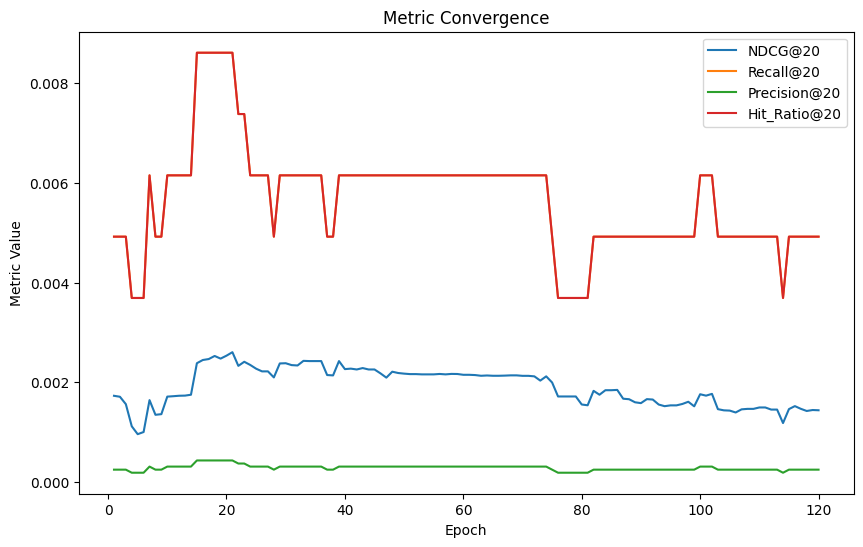

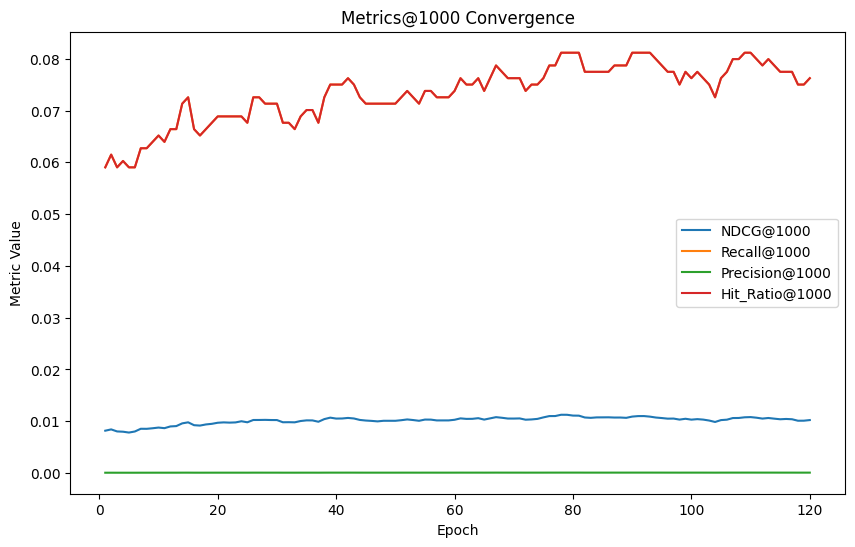

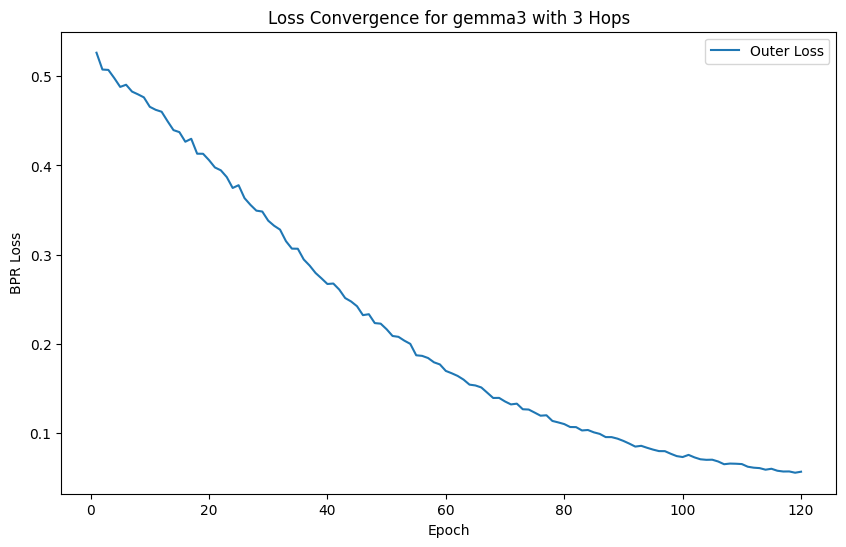

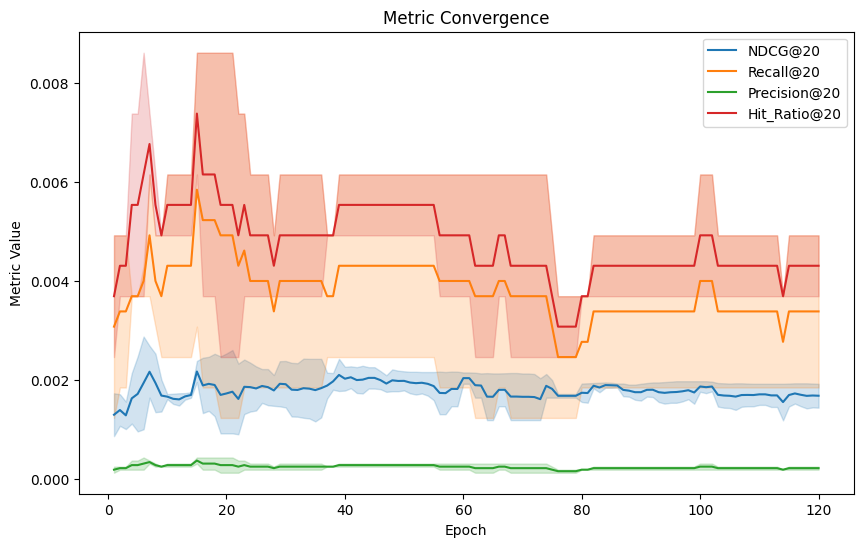

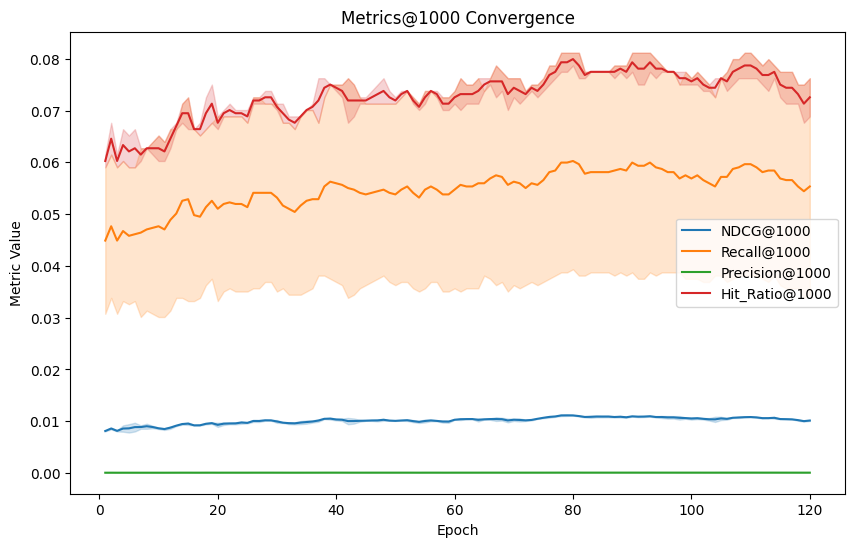

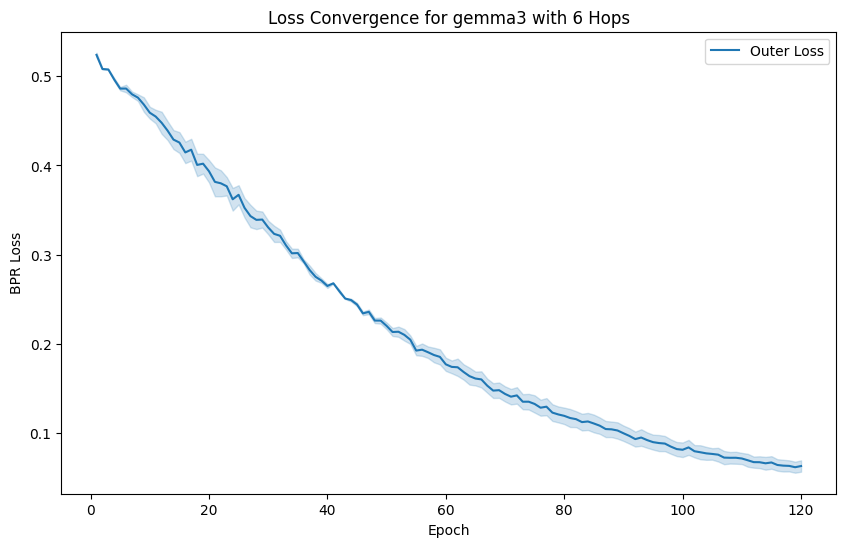

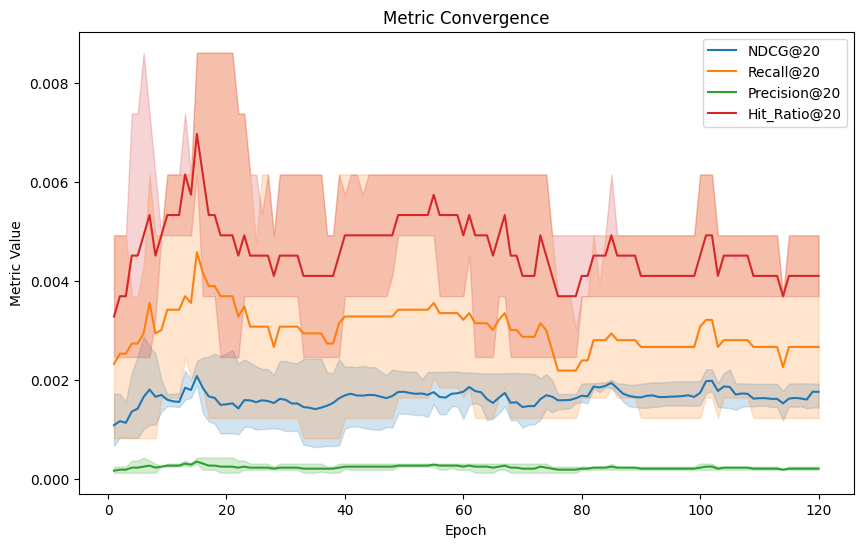

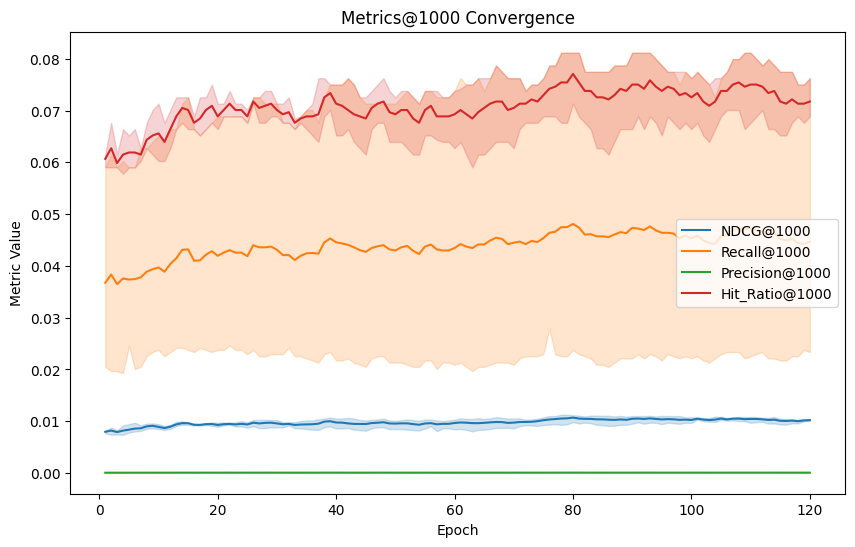

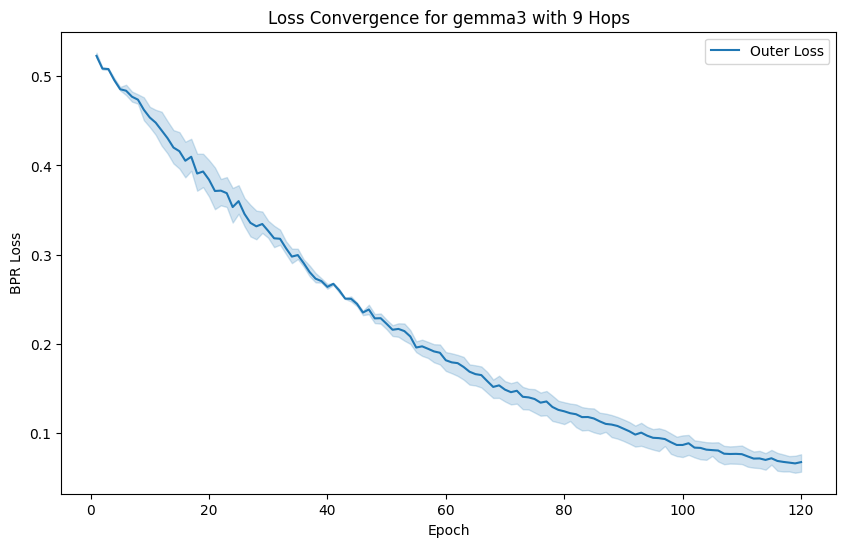

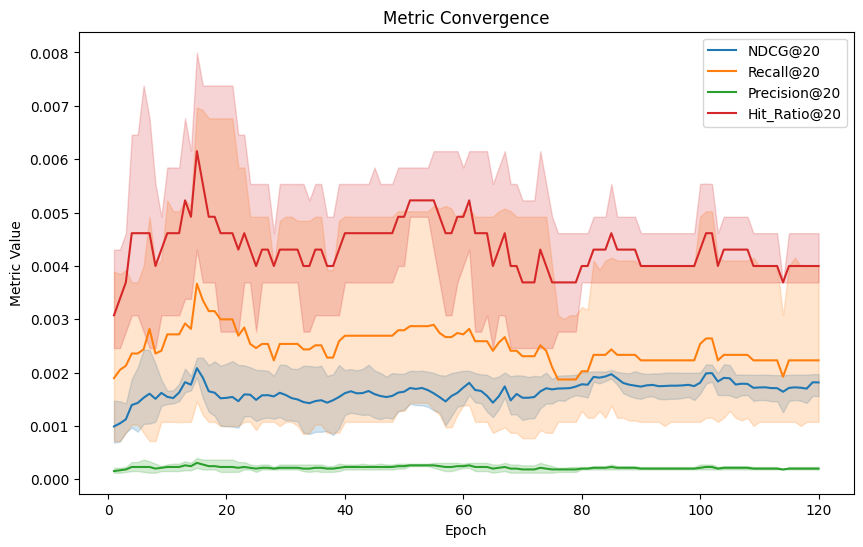

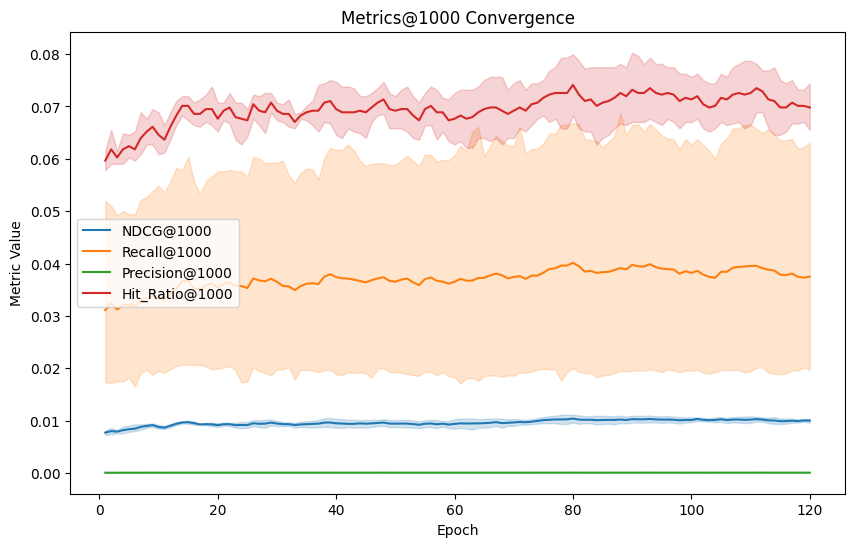

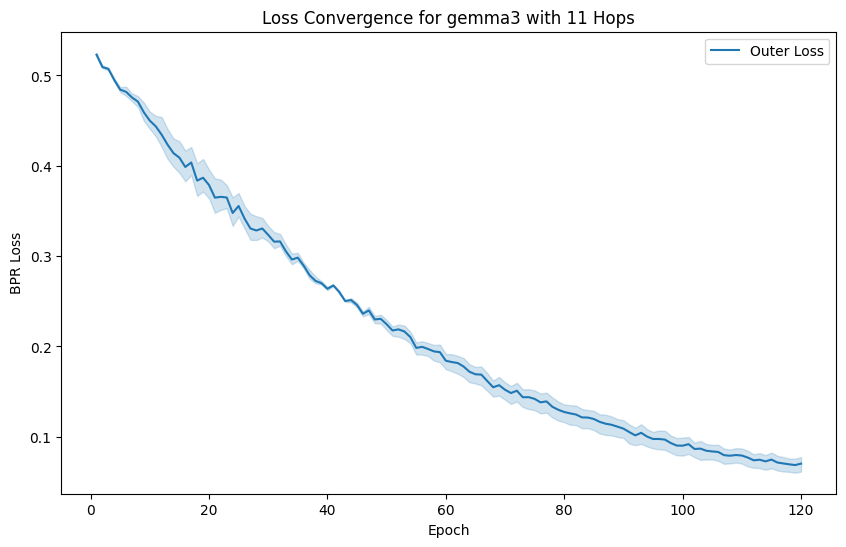

In [6]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender
import matplotlib.pyplot as plt
import seaborn as sns

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])


n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    MODEL_TECHNIQUE = "gemma3"
    EXPERIMENT_NAME = "#3 COL-Summary Step"
    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
    MLFLOW_EXPERIMENT_NAME = "#3 COL-Summary Step"
    mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
    
    df_metric_convergence = pd.DataFrame(columns=["Epoch", "NDCG@20", "Recall@20", "Precision@20", "Hit_Ratio@20", "N_CONTEXT_HOPS"])
    df_outer_loss = pd.DataFrame()


    STRATEGIES = ["only-summary","wo-grand-parents"]
    STRATEGIES = ["wo-grand-parents"]
    for STRATEGY in STRATEGIES:
        EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,STRATEGY)
        os.makedirs(EXPERIMENT_DATA_PATH,exist_ok=True)


        triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
        if STRATEGY == "only-summary":
            gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-summarized.csv')
        else:
            gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-{STRATEGY}_summarized.csv')
        data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
        metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
        train_df = pd.read_csv(data_path+'/train_df.csv')
        test_df = pd.read_csv(data_path+'/test_df.csv')
        build_kg = Build_KG()
        train_df = build_kg.user_item_triples(train_df)
        test_df = build_kg.user_item_triples(test_df)
        kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


        for N_CONTEXT_HOPS in [3,6,9,11]:
            
            with mlflow.start_run(run_name=f"{DATASET}-{STRATEGY}-{N_CONTEXT_HOPS}-Hops"):
                # Load relations
                # MODEL_TECHNIQUE = "gemma3"
                # EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

                # triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
                # if STRATEGY == "only-summary":
                #     gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-summarized.csv')
                # else:
                #     gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-{STRATEGY}_summarized.csv')
                # data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
                # metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
                # train_df = pd.read_csv(data_path+'/train_df.csv')
                # test_df = pd.read_csv(data_path+'/test_df.csv')
                # build_kg = Build_KG()
                # train_df = build_kg.user_item_triples(train_df)
                # test_df = build_kg.user_item_triples(test_df)
                # kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)

                seed = 2020
                sys.argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
                print(sys.argv)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False

                """read args"""
                global args, device
                args = parse_args()
                device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

                """build dataset"""
                train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
                adj_mat_list, norm_mat_list, mean_mat_list = mat_list

                gemma_density = nx.density(graph)
                print(f"Density of the graph: {gemma_density}")
                gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
                print(f"Average degree of the graph: {gemma_avg_degree}")
                gemma_max_degree = max(dict(nx.degree(graph)).values())
                print(f"Max degree of the graph: {gemma_max_degree}")

                print(f"Dataset statistics:")
                print(f"Number of training interactions: {len(train_cf)}")
                print(f"Number of test interactions: {len(test_cf)}")
                print(f"Number of users: {n_params['n_users']}")
                print(f"Number of items: {n_params['n_items']}")
                print(f"Batch size: {args.batch_size}")

                n_users = n_params['n_users']
                n_items = n_params['n_items']
                n_entities = n_params['n_entities']
                n_relations = n_params['n_relations']
                n_nodes = n_params['n_nodes']
                
                """cf data"""
                train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
                test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

                """define model"""
                augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
                model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
                
                """define optimizer"""
                rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
                aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
                model.augmenter = augmenter

                cur_best_pre_0 = 0
                stopping_step = 0
                should_stop = False
                total_iter = max(len(train_cf) // args.batch_size, 1)
                get_print = max(total_iter // 20, 1)
                
                print("start training ...")
                for epoch in range(args.epoch):
                    # Add epoch start print
                    print(f"\nEpoch {epoch+1}/{args.epoch}")
                    print(f"Number of iterations expected: {total_iter}")
                    
                    index = np.arange(len(train_cf))
                    np.random.shuffle(index)
                    model.train()

                    train_cf_pairs = train_cf_pairs[index]
                    total_outer_loss, total_inner_loss, s = 0, 0, 0
                    train_s_t = time()
                    iteration = 0
                    
                    # Add batch processing print
                    print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                    
                    while s + args.batch_size <= len(train_cf):
                        batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                        
                        # Debug print for first batch of first epoch
                        if epoch == 0 and iteration == 0:
                            print("\nFirst batch statistics:")
                            print(f"Users shape: {batch['users'].shape}")
                            print(f"Positive items shape: {batch['pos_items'].shape}")
                            print(f"Negative items shape: {batch['neg_items'].shape}")
                        
                        rec_loss, inv_mean, inv_var = model(batch)
                        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                        
                        # Debug print losses
                        if iteration % 100 == 0:
                            print(f"\nIteration {iteration} losses:")
                            print(f"rec_loss: {rec_loss.item():.6f}")
                            print(f"inv_mean: {inv_mean.item():.6f}")
                            print(f"inv_var: {inv_var.item():.6f}")
                            print(f"outer_loss: {outer_loss.item():.6f}")
                        
                        rec_optimizer.zero_grad()
                        outer_loss.backward()
                        
                        # Check gradients periodically
                        if iteration % 10 == 0:
                            print("\nGradient norms:")
                            for name, param in model.named_parameters():
                                if param.grad is not None:
                                    grad_norm = param.grad.data.norm(2).item()
                                    print(f"{name}: {grad_norm:.6f}")
                        
                        rec_optimizer.step()
                        total_outer_loss += outer_loss.item()

                        if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                            # Debug augmenter update
                            rec_loss, inv_mean, inv_var = model(batch)
                            inner_loss = - inv_var
                            
                            if iteration == 12:  # First augmenter update
                                print(f"\nAugmenter update:")
                                print(f"inner_loss: {inner_loss.item():.6f}")
                                print(f"inv_var: {inv_var.item():.6f}")
                            
                            aug_optimizer.zero_grad()
                            inner_loss.backward()
                            
                            # Debug augmenter gradients
                            if iteration == 12:
                                print("\nAugmenter gradient norms:")
                                for name, param in augmenter.named_parameters():
                                    if param.grad is not None:
                                        print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                            
                            aug_optimizer.step()
                            total_inner_loss += inner_loss.item()

                        s += args.batch_size
                        iteration += 1
                        inner_loss = - inv_var
                        if iteration % get_print == 0:
                            print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                            .format(epoch + 1, args.epoch, 
                                    iteration, total_iter, 
                                    outer_loss.item(), 
                                    inner_loss.item(),
                                    (time() - train_s_t) / 60))

                    train_e_t = time()
                    print("-" * 100)
                    print("start evluation ...")
                    print("-" * 100)
                    test_s_t = time()
                    ret,gemma_predictions = test(model, user_dict, n_params)
                    # save predictions
                    os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                    gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                    
                    test_e_t = time()
                    epoch_outer_loss = total_outer_loss  / total_iter
                    epoch_inner_loss = total_inner_loss  / total_iter
                    train_time = (train_e_t - train_s_t) / 60
                    test_time = (test_e_t - test_s_t) / 60
                    
                    # Create a pretty table for metrics
                    gemma_metrics_table = PrettyTable()
                    gemma_metrics_table.field_names = ["Metric", "Value"]
                    
                    # Add all available metrics
                    for k_idx, k in enumerate(eval(args.Ks)):
                        gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                    
                    recall_20 = ret['recall'][0]
                    ndcg_20 = ret['ndcg'][0]
                    precision_20 = ret['precision'][0]
                    hit_ratio_20 = ret['hit_ratio'][0]
                    
                    gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                    gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                    gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                    gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                    gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                    
                    print("\nEvaluation Metrics:")
                    print(gemma_metrics_table)
                    print("-" * 100)
                    
                    # Convert PrettyTable to pandas DataFrame
                    gemma_metrics_df = pd.DataFrame(gemma_metrics_table.rows, columns=gemma_metrics_table.field_names)
                    os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                    gemma_metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                
                    # Keep the original print for consistency
                
                    print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                        .format(epoch + 1, args.epoch, 
                                epoch_outer_loss, epoch_inner_loss,
                                recall_20, ndcg_20,
                                train_time, test_time))
                    print("-" * 100)


                    recall_1000 = ret['recall'][4]
                    ndcg_1000 = ret['ndcg'][4]
                    precision_1000 = ret['precision'][4]
                    hit_ratio_1000 = ret['hit_ratio'][4]

                # Append metrics for current epoch to convergence dataframe
                    df_epoch_metrics = pd.DataFrame([{
                        "Epoch": epoch + 1,
                        "Recall@20": recall_20,
                        "NDCG@20": ndcg_20,
                        "Precision@20": precision_20,
                        "Hit_Ratio@20": hit_ratio_20,
                        "Recall@1000": recall_1000,
                        "NDCG@1000": ndcg_1000,
                        "Precision@1000": precision_1000,
                        "Hit_Ratio@1000": hit_ratio_1000,
                        "n_context_hops": N_CONTEXT_HOPS
                    }])

                    df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                    df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                            "Epoch": [epoch + 1],
                            "Outer Loss": [epoch_outer_loss],
                            "n_context_hops": [N_CONTEXT_HOPS]
                        })], ignore_index=True)


            # --- MLflow Parameter Logging ---
            print("Logging parameters to MLflow...")
            mlflow.log_param("model_technique", MODEL_TECHNIQUE)
            mlflow.log_param("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("dataset", DATASET)
            mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
            mlflow.log_metric("precision_20", precision_20)
            mlflow.log_metric("hit_ratio_20", hit_ratio_20)
            mlflow.log_metric("recall_20", recall_20)
            mlflow.log_metric("ndcg_20", ndcg_20)
            mlflow.log_metric("auc", f"{ret['auc']:.4f}")
            mlflow.log_metric("train_time", f"{train_time:.2f}")
            mlflow.log_metric("test_time", f"{test_time:.2f}")
            mlflow.log_metric("max_path_length", f"{gemma_max_degree:.2f}")
            mlflow.log_metric("density", f"{gemma_density:.2f}")
            mlflow.end_run()
            # make plot of df_metric_convergence
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
            plt.title("Metric Convergence")
            plt.xlabel("Epoch")
            plt.ylabel("Metric Value")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric_convergence.png")
            plt.figure(figsize=(10, 6))
            # convergence @1000
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
            plt.title("Metrics@1000 Convergence")
            plt.xlabel("Epoch")
            plt.ylabel("Metric Value")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@100_convergence.png")

            # make plot of df_outer_loss
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
            plt.title(f"Loss Convergence for {MODEL_TECHNIQUE} with {N_CONTEXT_HOPS} Hops")
            plt.xlabel("Epoch")
            plt.ylabel("BPR Loss")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")


In [11]:
# Log metrics to MLflow

N_CONTEXT_HOPS = [3,6,9,11]
metrics_df = pd.DataFrame()
for N_CONTEXT_HOP in N_CONTEXT_HOPS:
    # Construct the file path
    file_path = f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOP}-Hops_acc_df.csv"
    try:
        # load metrics csv and concat
        n_hops_metrics_df = pd.read_csv(file_path)
        n_hops_metrics_df["n_hops"] = N_CONTEXT_HOP
        metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)
    except FileNotFoundError:
        print(f"Warning: File not found - {file_path}")
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Log metrics grouped by redundancy strategy

    # Check if the filtered dataframe is empty before logging
if not metrics_df.empty:
    # filter metrics
    mlflow.set_experiment(f"{MLFLOW_EXPERIMENT_NAME}")
    with mlflow.start_run(run_name=f"{DATASET}-Metrics-{N_CONTEXT_HOPS}-Hops"):
        mlflow.log_param("dataset", DATASET)
        mlflow.log_param("model_technique", MODEL_TECHNIQUE)
        # log df
        # Use log_table which expects a pandas DataFrame
        mlflow.log_table(data=metrics_df, artifact_file="metrics_summary.json")
        print(f"Logged metrics for {N_CONTEXT_HOPS}-Hops to MLflow.")
else:
    print(f"No metrics found for {N_CONTEXT_HOPS}-Hops, skipping MLflow logging.")



Logged metrics for [3, 6, 9, 11, 13]-Hops to MLflow.
